In [2]:
import seaborn as sns
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

###### 

In [9]:
import seaborn as sns 
titanic = sns.load_dataset("titanic") 
#print(titanic) 
#print(titanic.head(20)) 
#print(titanic.tail(20)) 
titanic.info() 
#titanic.shape
'''
def classification(self,sex,age):
     self._init_()
    age = self.age
    sex = self.sex
    return classification
'''
titanic.isnull().sum() 
titanic.isnull().mean() * 100 
titanic['survived'].value_counts() 
titanic['survived'].value_counts(normalize=True) * 100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [10]:
titanic.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [16]:
titanic.duplicates()

AttributeError: 'DataFrame' object has no attribute 'duplicates'

In [ ]:
titanic["sex"].map( qqwwsssss)

import seaborn as sns 
titanic = sns.load_dataset("titanic") 
print(titanic)
print(titanic.head(20))
print(titanic.tail(20))
titanic.info()
titanic.isnull().sum()
titanic.isnull().mean() * 100
titanic['survived'].value_counts()
titanic['survived'].value_counts(normalize=True) * 100

In [15]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load data
titanic = sns.load_dataset("titanic")

# Select variables
data = titanic[['survived','sex','age','pclass','embark_town']].dropna()

X = data.drop('survived', axis=1)
y = data['survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Encode categorical variables
categorical = ['sex','embark_town']
numeric = ['age','pclass']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical),
        ('num', 'passthrough', numeric)
    ])

# Logistic regression pipeline
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

# Predictions
y_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]))

Logistic Regression Accuracy: 0.7850467289719626
Logistic Regression AUC: 0.8061742694226657


In [16]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=4, random_state=42))
])

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Decision Tree AUC:", roc_auc_score(y_test, tree_model.predict_proba(X_test)[:,1]))

Decision Tree Accuracy: 0.7429906542056075
Decision Tree AUC: 0.7388186029935851


             Missing Count  Missing Percentage
deck                   688           77.216611
age                    177           19.865320
embarked                 2            0.224467
embark_town              2            0.224467
survived                 0            0.000000
pclass                   0            0.000000
sex                      0            0.000000
sibsp                    0            0.000000
parch                    0            0.000000
fare                     0            0.000000
class                    0            0.000000
who                      0            0.000000
adult_male               0            0.000000
alive                    0            0.000000
alone                    0            0.000000
Survival Distribution:
 survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

Logistic Regression Performance:
Accuracy: 0.8045
F1 Score: 0.7200
              precision    recall  f1-score   support

           0       0.80      

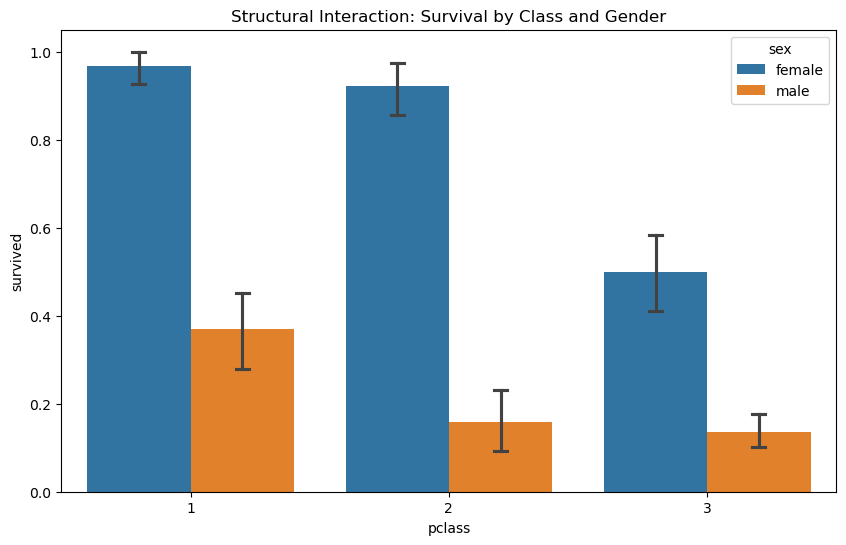

Optimization terminated successfully.
         Current function value: 0.437143
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  889
Model:                          Logit   Df Residuals:                      878
Method:                           MLE   Df Model:                           10
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                  0.3429
Time:                        21:07:44   Log-Likelihood:                -388.62
converged:                       True   LL-Null:                       -591.41
Covariance Type:            nonrobust   LLR p-value:                 6.115e-81
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       3.4935      0.514      6.802      0.000       2.487   

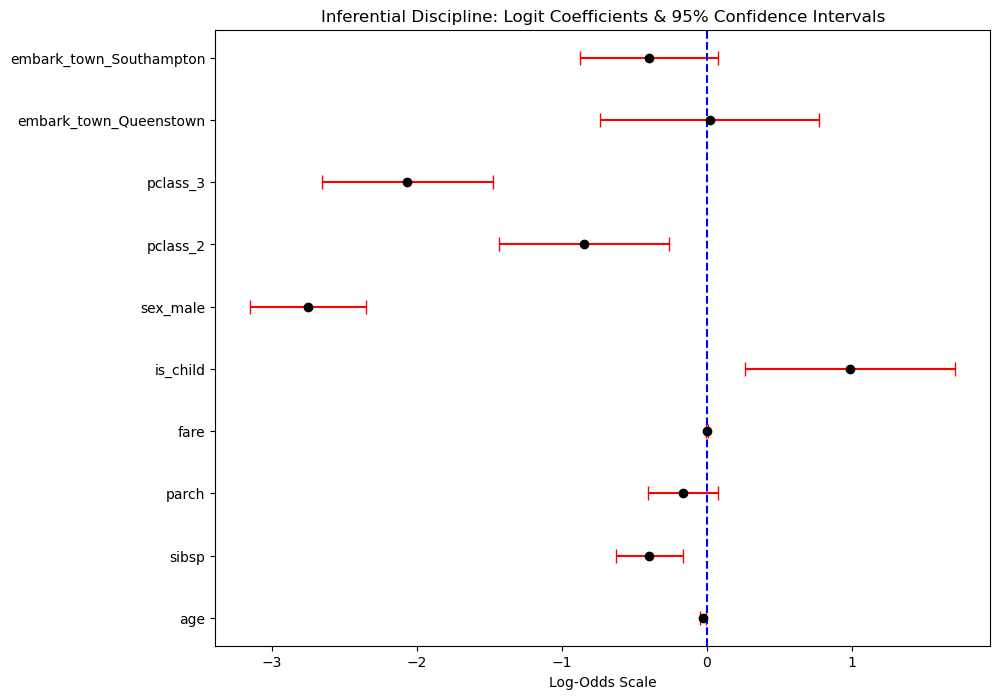

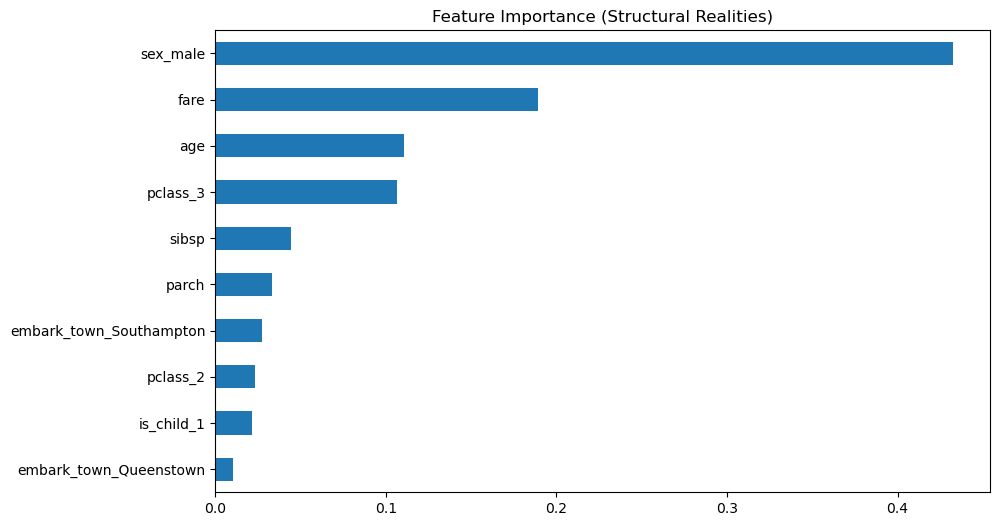

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

titanic = sns.load_dataset("titanic")

missing_summary = pd.DataFrame({
    "Missing Count": titanic.isnull().sum(),
    "Missing Percentage": (titanic.isnull().sum() / len(titanic)) * 100
}).sort_values(by="Missing Percentage", ascending=False)
print(missing_summary)

print("Survival Distribution:\n", titanic['survived'].value_counts(normalize=True) * 100)

data = titanic[['survived', 'sex', 'age', 'pclass', 'sibsp', 'parch', 'fare', 'embark_town']].copy()
data['is_child'] = (data['age'] < 18).astype(int)

X = data.drop('survived', axis=1)
y = data['survived']

numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'pclass', 'embark_town', 'is_child']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, C=1.0))
])

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
])

for name, model in [("Logistic Regression", log_model), ("Random Forest", rf_model)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

cv_log = cross_val_score(log_model, X, y, cv=5, scoring='f1')
cv_rf = cross_val_score(rf_model, X, y, cv=5, scoring='f1')
print(f"\nCV F1 Mean - Logistic: {np.mean(cv_log):.4f} (+/- {np.std(cv_log):.4f})")
print(f"CV F1 Mean - Random Forest: {np.mean(cv_rf):.4f} (+/- {np.std(cv_rf):.4f})")

plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='pclass', y='survived', hue='sex', capsize=.1)
plt.title("Structural Interaction: Survival by Class and Gender")
plt.show()



data_final = data.dropna(subset=['embark_town'])
data_dummies = pd.get_dummies(data_final, columns=['sex', 'pclass', 'embark_town'], drop_first=True)
data_dummies['age'] = data_dummies['age'].fillna(data_dummies['age'].median())

X_sm = data_dummies.drop('survived', axis=1).astype(float)
y_sm = data_dummies['survived']
X_sm = sm.add_constant(X_sm)
logit_res = sm.Logit(y_sm, X_sm).fit()
print(logit_res.summary())

summary_df = logit_res.conf_int()
summary_df['Coef'] = logit_res.params
summary_df.columns = ['Lower', 'Upper', 'Coef']
summary_df = summary_df.drop('const')

plt.figure(figsize=(10, 8))
plt.errorbar(summary_df['Coef'], summary_df.index, 
             xerr=[summary_df['Coef'] - summary_df['Lower'], summary_df['Upper'] - summary_df['Coef']],
             fmt='o', color='black', ecolor='red', capsize=5)
plt.axvline(x=0, color='blue', linestyle='--')
plt.title("Inferential Discipline: Logit Coefficients & 95% Confidence Intervals")
plt.xlabel("Log-Odds Scale")
plt.show()



rf_inner = rf_model.named_steps['classifier']
ohe_features = list(rf_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
feature_names = numeric_features + ohe_features
importances = pd.Series(rf_inner.feature_importances_, index=feature_names).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.title("Feature Importance (Structural Realities)")
plt.show()

In [6]:
import pandas as pd
import seaborn as sns
import numpy as np

# Load the dataset
titanic = sns.load_dataset("titanic")

# Conduct a structured data audit: Check for missing values
print("Missing values before cleaning:")
print(titanic.isnull().sum())
# Grouped median imputation for 'age' based on 'pclass' (Handling MAR)
titanic['age'] = titanic.groupby('pclass')['age'].transform(lambda x: x.fillna(x.median()))

# The 'embarked' column (port of departure) only misses 2 values. 
# We can safely fill these with the most common port (the mode).
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
# Drop 'deck' because too much data is missing to accurately impute.
# Drop redundant columns to prevent our model from double-counting variables.
titanic = titanic.drop(columns=['deck', 'alive', 'class', 'who', 'adult_male', 'embark_town'])

# Check our work to ensure missing values are gone
print("\nMissing values after imputation:")
print(titanic.isnull().sum())


Missing values before cleaning:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing values after imputation:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


In [7]:
# Convert 'sex' into a binary numeric variable: 0 for male, 1 for female
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})

# One-hot encode the 'embarked' column
# This creates new columns (embarked_Q, embarked_S) with 1s and 0s. 
# 'drop_first=True' prevents a statistical issue called multicollinearity.
titanic = pd.get_dummies(titanic, columns=['embarked'], drop_first=True)

# View the clean, model-ready dataset
print("\nFirst 5 rows of the cleaned dataset:")
print(titanic.head())



First 5 rows of the cleaned dataset:
   survived  pclass  sex   age  sibsp  parch     fare  alone  embarked_Q  \
0         0       3    0  22.0      1      0   7.2500  False       False   
1         1       1    1  38.0      1      0  71.2833  False       False   
2         1       3    1  26.0      0      0   7.9250   True       False   
3         1       1    1  35.0      1      0  53.1000  False       False   
4         0       3    0  35.0      0      0   8.0500   True       False   

   embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


In [8]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import pandas as pd

# 1. Define your Predictors (X) and Outcome (y)
# 'survived' is our target. We drop it from X, and assign it to y.
X = titanic.drop(columns=['survived'])
y = titanic['survived']

# 2. Train-Test Split
# We keep 20% of the data completely unseen to test our final models.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# MODEL 1: LOGISTIC REGRESSION
# ==========================================
print("--- LOGISTIC REGRESSION ---")
# Initialize the model (max_iter increased to help the math converge)
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Assess Stability using 5-Fold Cross-Validation
cv_scores_log = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores_log}")
print(f"Average CV Accuracy: {cv_scores_log.mean():.2f}\n")

# Train the model and evaluate on the unseen test set
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# Print metrics beyond accuracy (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

# Extract Coefficients to interpret "Structural Realities"
# A positive number means it increases survival odds; negative means it decreases them.
log_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print("Logistic Regression Coefficients:\n", log_coefficients)
print("\n" + "="*40 + "\n")

# ==========================================
# MODEL 2: DECISION TREE
# ==========================================
print("--- DECISION TREE CLASSIFIER ---")
# Initialize the model (limiting depth prevents the model from just memorizing the data)
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Assess Stability using 5-Fold Cross-Validation
cv_scores_tree = cross_val_score(tree_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores_tree}")
print(f"Average CV Accuracy: {cv_scores_tree.mean():.2f}\n")

# Train and evaluate
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_tree))

# Extract Feature Importance
# This ranges from 0 to 1, showing which variables the tree relied on most to split the data.
tree_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("Decision Tree Feature Importance:\n", tree_importance)

--- LOGISTIC REGRESSION ---
Cross-Validation Accuracy Scores: [0.81818182 0.8041958  0.80985915 0.73943662 0.82394366]
Average CV Accuracy: 0.80

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Logistic Regression Coefficients:
       Feature  Coefficient
1         sex     2.531528
5        fare     0.002110
2         age    -0.031583
7  embarked_Q    -0.087002
4       parch    -0.243011
8  embarked_S    -0.323380
3       sibsp    -0.458691
6       alone    -0.631488
0      pclass    -0.944469


--- DECISION TREE CLASSIFIER ---
Cross-Validation Accuracy Scores: [0.8041958  0.82517483 0.78169014 0.77464789 0.83098592]
Average CV Accuracy: 0.80

Classification Report:
              precision

             Missing Count  Missing Percentage
deck                   688           77.216611
age                    177           19.865320
embarked                 2            0.224467
embark_town              2            0.224467
survived                 0            0.000000
pclass                   0            0.000000
sex                      0            0.000000
sibsp                    0            0.000000
parch                    0            0.000000
fare                     0            0.000000
class                    0            0.000000
who                      0            0.000000
adult_male               0            0.000000
alive                    0            0.000000
alone                    0            0.000000
Survival Distribution (%):
 survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

Logistic Regression Performance:
Accuracy: 0.8045
Precision: 0.8036
Recall: 0.6522
F1 Score: 0.7200
              precision    recall  f1-score   s

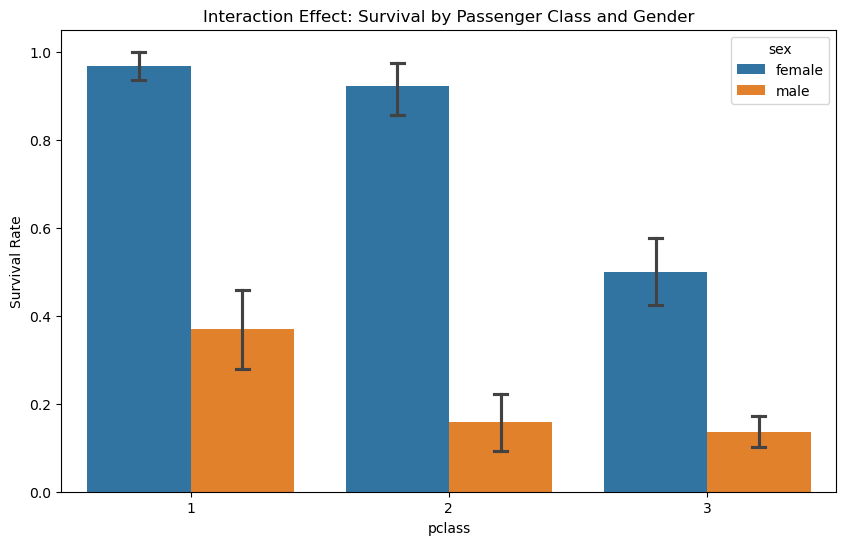

Optimization terminated successfully.
         Current function value: 0.437143
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  889
Model:                          Logit   Df Residuals:                      878
Method:                           MLE   Df Model:                           10
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                  0.3429
Time:                        19:09:55   Log-Likelihood:                -388.62
converged:                       True   LL-Null:                       -591.41
Covariance Type:            nonrobust   LLR p-value:                 6.115e-81
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       3.4935      0.514      6.802      0.000       2.487   

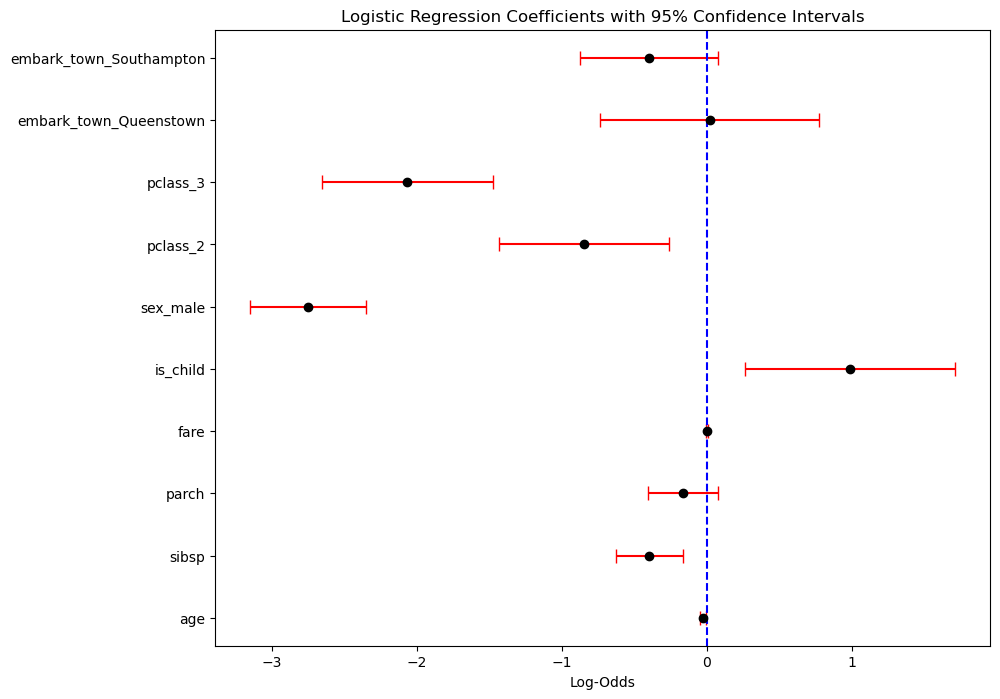

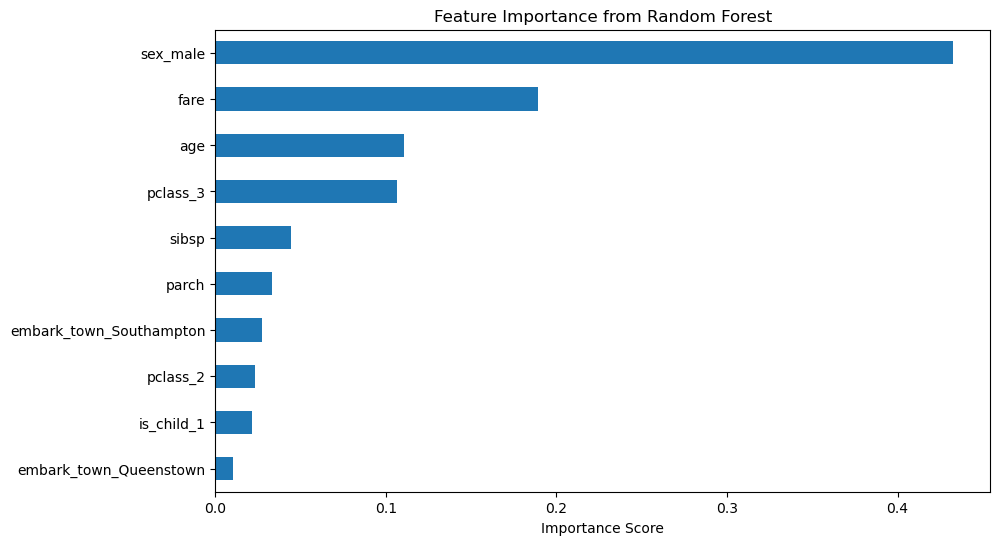

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load dataset
titanic = sns.load_dataset("titanic")

# Assess missing data (used in data audit section)
missing_summary = pd.DataFrame({
    "Missing Count": titanic.isnull().sum(),
    "Missing Percentage": (titanic.isnull().sum() / len(titanic)) * 100
}).sort_values(by="Missing Percentage", ascending=False)
print(missing_summary)

# Check class imbalance in survival
print("Survival Distribution (%):\n", titanic['survived'].value_counts(normalize=True) * 100)

# Select variables used in modeling
data = titanic[['survived', 'sex', 'age', 'pclass', 'sibsp', 'parch', 'fare', 'embark_town']].copy()

# Create child indicator to reflect "children first" assumption
data['is_child'] = (data['age'] < 18).astype(int)

# Define predictors and outcome
X = data.drop('survived', axis=1)
y = data['survived']

# Separate numeric and categorical variables
numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'pclass', 'embark_town', 'is_child']

# Handle missing values and scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # median used due to skewness in age
    ('scaler', StandardScaler())
])

# Encode categorical variables for model use
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Split data (stratified due to class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression model (used for interpretability)
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Random Forest model (used for capturing non-linear patterns)
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
])

# Train and evaluate both models
for name, model in [("Logistic Regression", log_model), ("Random Forest", rf_model)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

# Cross-validation to assess model stability
cv_log = cross_val_score(log_model, X, y, cv=5, scoring='f1')
cv_rf = cross_val_score(rf_model, X, y, cv=5, scoring='f1')

print(f"\nCV F1 Mean - Logistic: {np.mean(cv_log):.4f} (+/- {np.std(cv_log):.4f})")
print(f"CV F1 Mean - Random Forest: {np.mean(cv_rf):.4f} (+/- {np.std(cv_rf):.4f})")

# Visualizing interaction effect (class × gender)
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='pclass', y='survived', hue='sex', capsize=.1)
plt.title("Interaction Effect: Survival by Passenger Class and Gender")
plt.ylabel("Survival Rate")
plt.show()

# Prepare data for statistical inference using statsmodels
data_final = data.dropna(subset=['embark_town'])

data_dummies = pd.get_dummies(
    data_final,
    columns=['sex', 'pclass', 'embark_town'],
    drop_first=True
)

# Median imputation for age (consistent with preprocessing decisions)
data_dummies['age'] = data_dummies['age'].fillna(data_dummies['age'].median())

X_sm = data_dummies.drop('survived', axis=1).astype(float)
y_sm = data_dummies['survived']

X_sm = sm.add_constant(X_sm)

# Logistic regression for coefficient interpretation
logit_res = sm.Logit(y_sm, X_sm).fit()
print(logit_res.summary())

# Confidence interval visualization (shows uncertainty)
summary_df = logit_res.conf_int()
summary_df['Coef'] = logit_res.params
summary_df.columns = ['Lower', 'Upper', 'Coef']
summary_df = summary_df.drop('const')

plt.figure(figsize=(10, 8))
plt.errorbar(summary_df['Coef'], summary_df.index,
             xerr=[summary_df['Coef'] - summary_df['Lower'], summary_df['Upper'] - summary_df['Coef']],
             fmt='o', color='black', ecolor='red', capsize=5)
plt.axvline(x=0, color='blue', linestyle='--')
plt.title("Logistic Regression Coefficients with 95% Confidence Intervals")
plt.xlabel("Log-Odds")
plt.show()

# Feature importance from Random Forest (to assess structural drivers)
rf_model.fit(X_train, y_train)
rf_inner = rf_model.named_steps['classifier']

ohe = rf_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
ohe_features = ohe.get_feature_names_out(categorical_features)

feature_names = numeric_features + list(ohe_features)

importances = pd.Series(rf_inner.feature_importances_, index=feature_names).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance Score")
plt.show()